In [1]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 26.2 MB/s eta 0:00:00


In [2]:
# =========================
# Librerías
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import optuna
import warnings
import json
import joblib
from tqdm import tqdm



# =====================================================
# CARGAR DATOS
# =====================================================

df = pd.read_csv('/content/CPT_FIN.csv', encoding='latin-1')


# =====================================================
# ELIMINACIÓN DE SONDEOS PROBLEMÁTICOS
# =====================================================

sondeos_eliminar = ['CPTu-157-P2']
df = df[~df["Sondeo"].isin(sondeos_eliminar)].copy()


# =========================
# Filtrado espacial
# =========================

xmin, xmax = 478000, 479000
ymin, ymax = 2036500, 2037500
df = df[df['X'].between(xmin, xmax) & df['Y'].between(ymin, ymax)]


# =====================================================
# VARIABLE OBJETIVO
# =====================================================

df['value'] = df['Tip resistance Mpa']


# =========================
# Outliers (global)
# =========================

Q1 = df['value'].quantile(0.25)
Q3 = df['value'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['value'] < lower_bound) | (df['value'] > upper_bound)]
print(f"Outliers eliminados: {len(outliers)}")

df = df[df['value'].between(lower_bound, upper_bound)].copy()

features = ['X', 'Y', 'Z']
sondeos = np.unique(df['Sondeo'].values)

print(f"Sondeos disponibles: {len(sondeos)}")
print(f"Observaciones (tras outliers): {len(df)}")

# =====================================================
# FUNCIÓN DE TUNING (con criterio de varianza)
# =====================================================

def tunear_rf(
    X_train,
    y_train,
    groups_train,
    n_trials=15,
    lambda_var=0.8,
):
    logo = LeaveOneGroupOut()
    folds = list(logo.split(X_train, y_train, groups_train))

    def objective(trial):
        params = dict(
            n_estimators=50,
            max_depth=trial.suggest_int("max_depth", 5, 25),
            min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 15),
            max_features=3,
            bootstrap=True,
            random_state=42,
            n_jobs=-1,
        )

        rf = RandomForestRegressor(**params)

        y_true_cv = []
        y_pred_cv = []
        r2_train = []

        for i, (tr_idx, va_idx) in enumerate(folds):
            rf.fit(X_train[tr_idx], y_train[tr_idx])
            pred_train = rf.predict(X_train[tr_idx])
            pred_val = rf.predict(X_train[va_idx])

            r2_train.append(r2_score(y_train[tr_idx], pred_train))
            y_true_cv.extend(y_train[va_idx])
            y_pred_cv.extend(pred_val)

            # Pruning
            if i >= 4:
                r2_parcial = r2_score(y_true_cv, y_pred_cv)
                trial.report(r2_parcial, i)
                if trial.should_prune():
                    raise optuna.TrialPruned()

        y_true_cv = np.asarray(y_true_cv)
        y_pred_cv = np.asarray(y_pred_cv)

        # R² validación
        r2_val = r2_score(y_true_cv, y_pred_cv)

        # Ratio de varianzas
        var_ratio = np.var(y_pred_cv) / (np.var(y_true_cv) + 1e-9)
        penal_var = abs(1.0 - var_ratio)

        # Función objetivo
        score = r2_val - lambda_var * penal_var

        # Atributos para inspección
        trial.set_user_attr("r2_val", r2_val)
        trial.set_user_attr("var_ratio", var_ratio)
        trial.set_user_attr("penal_var", penal_var)
        trial.set_user_attr("gap", np.mean(r2_train) - r2_val)
        trial.set_user_attr("score", score)

        return score

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(multivariate=True, seed=42),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=4),
    )

    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    print("\nMejor score:", round(study.best_value, 4))
    print("R² val:", round(study.best_trial.user_attrs["r2_val"], 4))
    print("Var ratio:", round(study.best_trial.user_attrs["var_ratio"], 4))
    print("Gap:", round(study.best_trial.user_attrs["gap"], 4))

    return study.best_params


# =====================================================
# LOGO EXTERNO (nested CV)
# =====================================================

y_true_all, y_pred_all, group_ids_all = [], [], []
r2_train_folds, r2_test_folds, sondeo_folds, best_params_folds = [], [], [], []

n_total = len(sondeos)
print(f"\nEjecutando LOGO anidado sobre {n_total} sondeos...\n")

barra = tqdm(sondeos, total=n_total, desc="LOGO externo")

for sondeo_out in barra:

    train_df = df[df['Sondeo'] != sondeo_out]
    test_df  = df[df['Sondeo'] == sondeo_out]

    if len(train_df) == 0 or len(test_df) == 0:
        barra.set_postfix_str(f"{sondeo_out}: sin datos, omitido")
        continue

    X_train = train_df[features].values
    y_train = train_df['value'].values
    groups_train = train_df['Sondeo'].values

    X_test = test_df[features].values
    y_test = test_df['value'].values

    # Tuning con criterio de varianza
    best_params = tunear_rf(X_train, y_train, groups_train, n_trials=15, lambda_var=0.1)
    best_params_folds.append({**best_params, "Sondeo": sondeo_out})

    # Modelo final del fold
    rf = RandomForestRegressor(
        **best_params,
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)

    preds_train = rf.predict(X_train)
    preds_test  = rf.predict(X_test)

    r2_tr = r2_score(y_train, preds_train)
    r2_te = r2_score(y_test, preds_test)

    r2_train_folds.append(r2_tr)
    r2_test_folds.append(r2_te)
    sondeo_folds.append(sondeo_out)

    y_true_all.extend(y_test)
    y_pred_all.extend(preds_test)
    group_ids_all.extend([sondeo_out] * len(y_test))

    barra.set_postfix_str(f"{sondeo_out}: R2_train={r2_tr:.3f} R2_test={r2_te:.3f}")

y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)
group_ids_all = np.array(group_ids_all)


# =====================================================
# MÉTRICAS GLOBALES
# =====================================================

r2_logo = r2_score(y_true_all, y_pred_all)
rmse_logo = np.sqrt(mean_squared_error(y_true_all, y_pred_all))
mae_logo = mean_absolute_error(y_true_all, y_pred_all)
r2_train_mean = np.mean(r2_train_folds)
var_ratio_global = np.var(y_pred_all) / np.var(y_true_all)

print("\n==========================")
print("RESULTADOS LOGO (nested)")
print("==========================")
print(f"R2 train promedio: {r2_train_mean:.3f}")
print(f"R2 LOGO:           {r2_logo:.3f}")
print(f"RMSE:              {rmse_logo:.3f}")
print(f"MAE:               {mae_logo:.3f}")
print(f"Gap:               {r2_train_mean - r2_logo:.3f}")
print(f"Variance ratio:    {var_ratio_global:.3f}")


# =====================================================
# RESULTADOS POR FOLD
# =====================================================

resultados_fold = pd.DataFrame({
    "Sondeo": sondeo_folds,
    "R2_train": r2_train_folds,
    "R2_test": r2_test_folds
})
resultados_fold["Gap"] = resultados_fold["R2_train"] - resultados_fold["R2_test"]

print("\nResultados por fold:")
print(resultados_fold.sort_values("R2_test"))

resultado = pd.DataFrame({
    "Sondeo": group_ids_all,
    "real": y_true_all,
    "pred": y_pred_all
})



# =====================================================
# MODELO DE PRODUCCIÓN
# =====================================================

X_full = df[features].values
y_full = df['value'].values
groups_full = df['Sondeo'].values

print("\nRe-tuneando hiperparámetros con todos los datos para el modelo final...")

best_params_full = tunear_rf(X_full, y_full, groups_full, n_trials=15, lambda_var=0.1)

rf_final = RandomForestRegressor(
    **best_params_full,
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)
rf_final.fit(X_full, y_full)



Outliers eliminados: 345
Sondeos disponibles: 15
Observaciones (tras outliers): 26390

Ejecutando LOGO anidado sobre 15 sondeos...



LOGO externo:   0%|          | 0/15 [00:00<?, ?it/s]/tmp/ipykernel_1179/2556933819.py:145: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(multivariate=True, seed=42),
[I 2026-08-13 05:19:40,058] A new study created in memory with name: no-name-c564d36d-c8cb-47e1-95dc-66c778b00cf0
[I 2026-08-13 05:19:57,236] Trial 0 finished with value: 0.08491134017419519 and parameters: {'max_depth': 12, 'min_samples_leaf': 15}. Best is trial 0 with value: 0.08491134017419519.
[I 2026-08-13 05:20:15,915] Trial 1 finished with value: 0.06045510705357633 and parameters: {'max_depth': 20, 'min_samples_leaf': 9}. Best is trial 0 with value: 0.08491134017419519.
[I 2026-08-13 05:20:29,375] Trial 2 finished with value: 0.11531179730475943 and parameters: {'max_depth': 8, 'min_samples_leaf': 3}. Best is trial 2 with value: 0.11531179730475943.
[I 2026-08-13 05:20:40,230] Trial 3 finished with value: 0.199


Mejor score: 0.2048
R² val: 0.2582
Var ratio: 0.4658
Gap: 0.2881


LOGO externo:   7%|▋         | 1/15 [02:50<39:44, 170.30s/it, CPTu-01-P2: R2_train=0.540 R2_test=0.393]/tmp/ipykernel_1179/2556933819.py:145: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(multivariate=True, seed=42),
[I 2026-08-13 05:22:30,363] A new study created in memory with name: no-name-0fa0360d-7914-442e-ba4d-138179568583
[I 2026-08-13 05:22:46,322] Trial 0 finished with value: 0.12464085860398535 and parameters: {'max_depth': 12, 'min_samples_leaf': 15}. Best is trial 0 with value: 0.12464085860398535.
[I 2026-08-13 05:23:04,376] Trial 1 finished with value: 0.09916730972976384 and parameters: {'max_depth': 20, 'min_samples_leaf': 9}. Best is trial 0 with value: 0.12464085860398535.
[I 2026-08-13 05:23:17,705] Trial 2 finished with value: 0.1507466717314448 and parameters: {'max_depth': 8, 'min_samples_leaf': 3}. Best is trial 2 with value: 0.1507466717314448.
[I 2026-08-13


Mejor score: 0.2506
R² val: 0.3009
Var ratio: 0.4966
Gap: 0.2528


...

LOGO externo: 100%|██████████| 15/15 [41:56<00:00, 167.78s/it, CPTu-D-08-P2: R2_train=0.561 R2_test=0.075]
/tmp/ipykernel_1179/2556933819.py:145: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(multivariate=True, seed=42),
[I 2026-08-13 06:01:36,760] A new study created in memory with name: no-name-8ec469ac-e524-4f46-a827-29e32a304111



RESULTADOS LOGO (nested)
R2 train promedio: 0.567
R2 LOGO:           0.320
RMSE:              2.933
MAE:               2.258
Gap:               0.247
Variance ratio:    0.466

Resultados por fold:
          Sondeo  R2_train   R2_test       Gap
4    CPTu-123-P1  0.569623  0.037147  0.532475
14  CPTu-D-08-P2  0.560822  0.075449  0.485373
5    CPTu-126-P1  0.549867  0.140101  0.409766
6    CPTu-130-P2  0.559203  0.208545  0.350658
2    CPTu-113-P1  0.545684  0.216176  0.329508
8     CPTu-31-P2  0.647152  0.292659  0.354492
1     CPTu-05-P2  0.544368  0.304597  0.239771
13    CPTu-56-P2  0.638746  0.370371  0.268375
10    CPTu-38-P2  0.550819  0.371025  0.179795
9     CPTu-36-P2  0.540270  0.380664  0.159606
7    CPTu-131-P2  0.547837  0.389237  0.158600
0     CPTu-01-P2  0.539827  0.392849  0.146979
3    CPTu-114-P2  0.536242  0.431870  0.104372
11    CPTu-43-P2  0.540060  0.465305  0.074755
12    CPTu-48-P2  0.630045  0.685974 -0.055929

Re-tuneando hiperparámetros con todos los datos p

[I 2026-08-13 06:01:54,783] Trial 0 finished with value: 0.1316725689667075 and parameters: {'max_depth': 12, 'min_samples_leaf': 15}. Best is trial 0 with value: 0.1316725689667075.
[I 2026-08-13 06:02:16,408] Trial 1 finished with value: 0.09430425995905957 and parameters: {'max_depth': 20, 'min_samples_leaf': 9}. Best is trial 0 with value: 0.1316725689667075.
[I 2026-08-13 06:02:31,227] Trial 2 finished with value: 0.16228828403752507 and parameters: {'max_depth': 8, 'min_samples_leaf': 3}. Best is trial 2 with value: 0.16228828403752507.
[I 2026-08-13 06:02:43,136] Trial 3 finished with value: 0.2580148665313889 and parameters: {'max_depth': 6, 'min_samples_leaf': 13}. Best is trial 3 with value: 0.2580148665313889.
[I 2026-08-13 06:03:02,808] Trial 4 finished with value: 0.10928728478888819 and parameters: {'max_depth': 17, 'min_samples_leaf': 11}. Best is trial 3 with value: 0.2580148665313889.
[I 2026-08-13 06:03:13,205] Trial 5 finished with value: 0.25795149772811293 and para


Mejor score: 0.258
R² val: 0.3033
Var ratio: 0.5475
Gap: 0.3339


RandomForestRegressor(max_depth=6, min_samples_leaf=13, n_estimators=500,
                      n_jobs=-1, random_state=42)

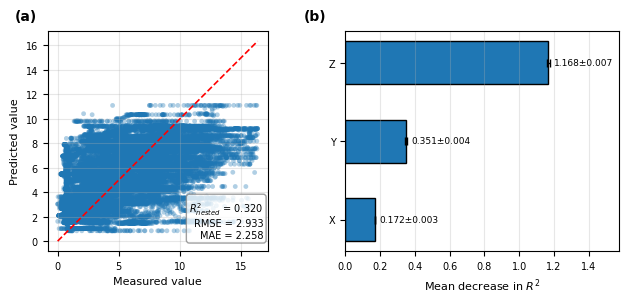

Table 1. Model performance metrics
Metric                   Value     
Training R2              0.567
Nested LOGOCV R2         0.320
RMSE                     2.933
MAE                      2.258
Generalization gap       0.247
Variance ratio           0.466


In [3]:
# =====================================================
# FIGURA 1x2 — scatter + feature importance (sin tablas embebidas)
# =====================================================
from sklearn.inspection import permutation_importance

# --- Permutation Feature Importance sobre el modelo final ---
X_full = df[features].values
y_full = df['value'].values

perm = permutation_importance(
    rf_final, X_full, y_full,
    n_repeats=30, random_state=42,
    scoring='r2', n_jobs=-1
)

order = np.argsort(perm.importances_mean)[::-1]
feat_sorted = [features[i] for i in order]
imp_mean = perm.importances_mean[order]
imp_std  = perm.importances_std[order]

# --- Tamaño en cm -> pulgadas (Wiley double-column ~17 cm) ---
cm = 1 / 2.54
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17 * cm, 8 * cm))

# =====================================================
# Panel (a): Real vs Predicho
# =====================================================
ax1.scatter(y_true_all, y_pred_all, alpha=0.35, s=12, c='#1f77b4', edgecolors='none')
lims = [min(y_true_all.min(), y_pred_all.min()),
        max(y_true_all.max(), y_pred_all.max())]
ax1.plot(lims, lims, 'r--', lw=1.2, label='1:1')
ax1.set_xlabel("Measured value", fontsize=8)
ax1.set_ylabel("Predicted value", fontsize=8)
ax1.tick_params(labelsize=7)
ax1.set_aspect('equal', adjustable='box')
ax1.grid(True, alpha=0.3)
#ax1.legend(loc='upper left', frameon=True, fontsize=7)
ax1.text(-0.15, 1.05, "(a)", transform=ax1.transAxes, fontsize=10, fontweight='bold')

# --- Anotación de métricas dentro del panel, no como tabla aparte ---
metrics_text = (f"$R^2_{{nested}}$ = {r2_logo:.3f}\n"
                 f"RMSE = {rmse_logo:.3f}\n"
                 f"MAE = {mae_logo:.3f}")
ax1.text(0.98, 0.05, metrics_text, transform=ax1.transAxes,
          fontsize=7, ha='right', va='bottom',
          bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='#888'))

# =====================================================
# Panel (b): Permutation Feature Importance (con valores anotados)
# =====================================================
y_pos = np.arange(len(feat_sorted))
ax2.barh(y_pos, imp_mean, xerr=imp_std,
          color='#1f77b4', edgecolor='black',
          height=0.55, capsize=3, error_kw={'elinewidth': 1})
ax2.set_yticks(y_pos)
ax2.set_yticklabels(feat_sorted, fontsize=8)
ax2.invert_yaxis()
ax2.set_xlabel("Mean decrease in $R^2$", fontsize=8)
ax2.tick_params(labelsize=7)
ax2.grid(axis='x', alpha=0.3)
ax2.set_xlim(0, max(imp_mean) * 1.35)
ax2.text(-0.15, 1.05, "(b)", transform=ax2.transAxes, fontsize=10, fontweight='bold')

for i, (m, s) in enumerate(zip(imp_mean, imp_std)):
    ax2.text(m + s + max(imp_mean) * 0.02, i, f"{m:.3f}±{s:.3f}",
              va='center', fontsize=6.5)

plt.tight_layout()
plt.savefig("figure_logo_importance.tiff", dpi=600, bbox_inches='tight')
plt.savefig("figure_logo_importance.pdf", bbox_inches='tight')  # respaldo vectorial
plt.show()

# =====================================================
# Tablas para el manuscrito (fuera de la figura)
# =====================================================
print("Table 1. Model performance metrics")
print(f"{'Metric':<25}{'Value':<10}")
print(f"{'Training R2':<25}{r2_train_mean:.3f}")
print(f"{'Nested LOGOCV R2':<25}{r2_logo:.3f}")
print(f"{'RMSE':<25}{rmse_logo:.3f}")
print(f"{'MAE':<25}{mae_logo:.3f}")
print(f"{'Generalization gap':<25}{r2_train_mean - r2_logo:.3f}")
print(f"{'Variance ratio':<25}{var_ratio_global:.3f}")

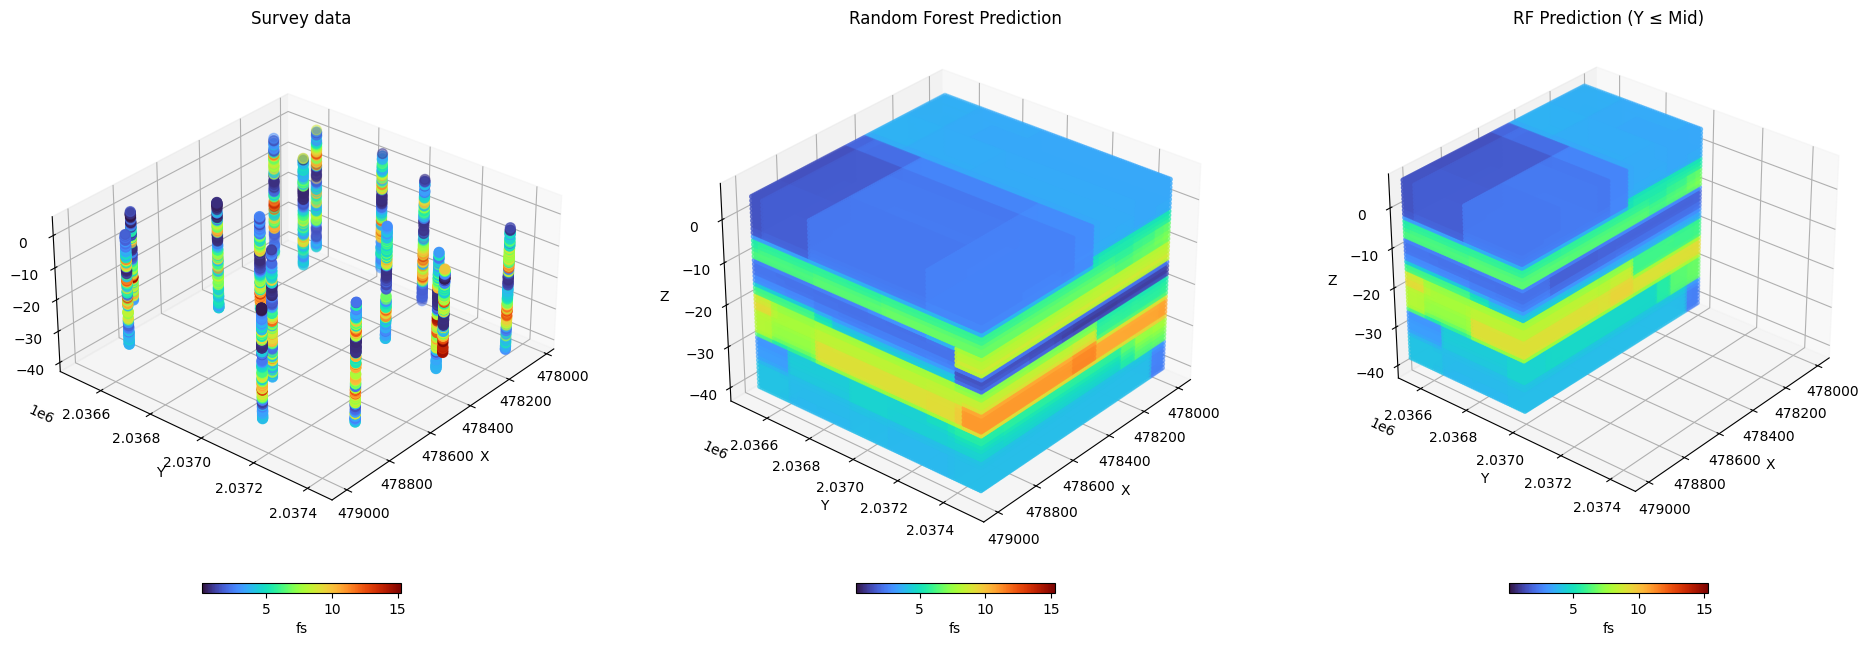

Archivo generado: fs_RF.csv.gz


In [ ]:
# =========================
# Crear malla 3D para predicción
# =========================

xmin, xmax = 478000, 479000
ymin, ymax = 2036500, 2037500
zmin, zmax = -40, 5


x_range = np.linspace(
    xmin,
    xmax,
    100
)

y_range = np.linspace(
    ymin,
    ymax,
    100
)

z_range = np.linspace(
    zmin,
    zmax,
    50
)


gx, gy, gz = np.meshgrid(
    x_range,
    y_range,
    z_range
)


grid_points = np.c_[

    gx.ravel(),
    gy.ravel(),
    gz.ravel()

]


# =========================
# Predicción Random Forest FINAL
# =========================

grid_pred = rf_final.predict(
    grid_points
)


# Escala común de colores

vmin = min(
    df['value'].min(),
    grid_pred.min()
)

vmax = max(
    df['value'].max(),
    grid_pred.max()
)


# Corte mitad inferior

mask_lower = (
    grid_points[:,1]
    <=
    (ymin+ymax)/2
)



# =========================
# Visualización 3D
# =========================

fig = plt.figure(
    figsize=(20,7)
)



# -------------------------------------------------
# Datos reales
# -------------------------------------------------

ax1 = fig.add_subplot(
    131,
    projection='3d'
)


sc1 = ax1.scatter(

    df['X'],
    df['Y'],
    df['Z'],

    c=df['value'],

    cmap='turbo',

    s=50,

    vmin=vmin,
    vmax=vmax

)


ax1.set_title(
    'Survey data'
)

ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')


ax1.set_box_aspect(
    [2,2,1]
)


ax1.view_init(
    elev=30,
    azim=40
)


fig.colorbar(
    sc1,
    ax=ax1,
    label='fs',
    shrink=0.3,
    orientation='horizontal',
    pad=0.05
)



# -------------------------------------------------
# Predicción RF completa
# -------------------------------------------------

ax2 = fig.add_subplot(
    132,
    projection='3d'
)


sc2 = ax2.scatter(

    grid_points[:,0],
    grid_points[:,1],
    grid_points[:,2],

    c=grid_pred,

    cmap='turbo',

    s=10,

    vmin=vmin,
    vmax=vmax

)


ax2.set_title(
    'Random Forest Prediction'
)

ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')


ax2.view_init(
    elev=30,
    azim=40
)


fig.colorbar(
    sc2,
    ax=ax2,
    label='fs',
    shrink=0.3,
    orientation='horizontal',
    pad=0.05
)



# -------------------------------------------------
# Predicción mitad inferior
# -------------------------------------------------

ax3 = fig.add_subplot(
    133,
    projection="3d"
)


sc3 = ax3.scatter(

    grid_points[mask_lower,0],
    grid_points[mask_lower,1],
    grid_points[mask_lower,2],

    c=grid_pred[mask_lower],

    cmap="turbo",

    s=10,

    vmin=vmin,
    vmax=vmax

)


ax3.set_title(
    "RF Prediction (Y ≤ Mid)"
)


ax3.set_xlabel("X")
ax3.set_ylabel("Y")
ax3.set_zlabel("Z")


ax3.set_ylim(
    ymin,
    ymax
)


ax3.view_init(
    elev=30,
    azim=40
)


cbar3 = fig.colorbar(
    sc3,
    ax=ax3,
    orientation='horizontal',
    pad=0.1,
    shrink=0.3
)


cbar3.set_label(
    "fs"
)



plt.tight_layout()

plt.show()



# =========================
# Guardar volumen 3D
# =========================

volume_df = pd.DataFrame({

    'X': gx.flatten(),

    'Y': gy.flatten(),

    'Z': gz.flatten(),

    'fs_pred': grid_pred.flatten()

})


# Guardar en Google Drive comprimido

volume_df.to_csv(
    '/content/drive/MyDrive/fs_RF.csv.gz',
    index=False,
    compression='gzip'
)


print("Archivo generado: fs_RF.csv.gz")

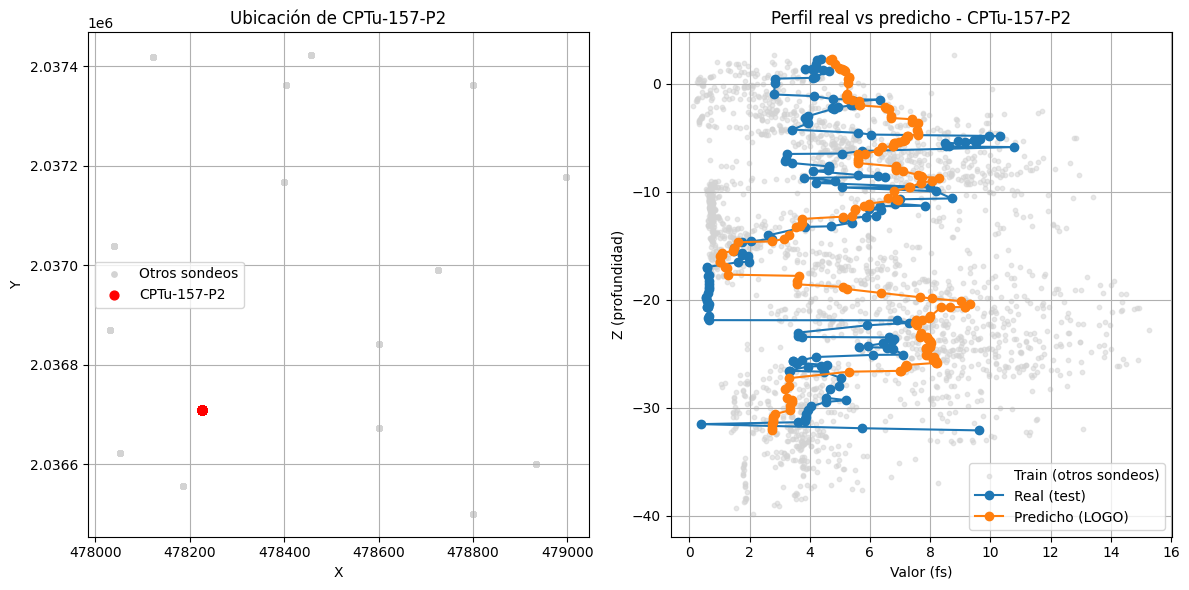

In [ ]:
sondeo_id = "CPTu-157-P2"

datos_sondeo = df[df['Sondeo'] == sondeo_id].sort_values('Z')
otros_sondeos = df[df['Sondeo'] != sondeo_id]

mask_pred = group_ids_all == sondeo_id
real_test = y_true_all[mask_pred]
pred_test = y_pred_all[mask_pred]

# reordenar predicho/real por Z para que la línea tenga sentido
z_test = datos_sondeo['Z'].values  # mismo orden que test_df en el LOGO (por sondeo, sin reshuffle)
orden = np.argsort(z_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# ---- Panel izquierdo: ubicación del sondeo (mapa X,Y) ----
axes[0].scatter(otros_sondeos['X'], otros_sondeos['Y'], c='lightgray', s=15, label='Otros sondeos')
axes[0].scatter(datos_sondeo['X'], datos_sondeo['Y'], c='red', s=40, label=sondeo_id)
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")
axes[0].set_title(f"Ubicación de {sondeo_id}")
axes[0].legend()
axes[0].grid(True)

# ---- Panel derecho: perfil real (train, sondeos vecinos) vs test (real y predicho) ----
axes[1].scatter(otros_sondeos['value'], otros_sondeos['Z'],
                 c='lightgray', s=10, alpha=0.5, label='Train (otros sondeos)')
axes[1].plot(real_test[orden], z_test[orden], '-o', color='tab:blue', label='Real (test)')
axes[1].plot(pred_test[orden], z_test[orden], '-o', color='tab:orange', label='Predicho (LOGO)')
axes[1].set_xlabel("Valor (fs)")
axes[1].set_ylabel("Z (profundidad)")
axes[1].set_title(f"Perfil real vs predicho - {sondeo_id}")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
def procesar(sondeo_df, sigma=3, n_samples=150):
    cols = ['X', 'Y', 'Z', 'value']
    sondeo_df[cols] = sondeo_df[cols].apply(pd.to_numeric, errors='coerce')
    sondeo_df = sondeo_df.dropna(subset=cols)
    sondeo_df = sondeo_df.sort_values(by='Z', ascending=False)

    # Diagnóstico de espaciado (opcional, solo para verificar consistencia)
    dz = sondeo_df['Z'].diff().abs().median()
    sondeo_df.attrs['dz_medio'] = dz

    sondeo_df['value'] = gaussian_filter1d(sondeo_df['value'], sigma=sigma)
    n_samples = min(n_samples, len(sondeo_df))
    return sondeo_df.sample(n=n_samples, random_state=42).sort_values(by='Z', ascending=False)

resultados = {i: procesar(df_s) for i, df_s in enumerate(CPT)}

# Revisar consistencia del espaciado entre sondeos
for i, r in resultados.items():
    print(f"Sondeo {i}: dz medio = {r.attrs.get('dz_medio', 'N/A'):.4f}")

Sondeo 0: dz medio = 0.0200
Sondeo 1: dz medio = 0.0200
Sondeo 2: dz medio = 0.0200
Sondeo 3: dz medio = 0.0200
Sondeo 4: dz medio = 0.0200
Sondeo 5: dz medio = 0.0200
Sondeo 6: dz medio = 0.0200
Sondeo 7: dz medio = 0.0200
Sondeo 8: dz medio = 0.0200
Sondeo 9: dz medio = 0.0200
Sondeo 10: dz medio = 0.0200
Sondeo 11: dz medio = 0.0200
Sondeo 12: dz medio = 0.0200
Sondeo 13: dz medio = 0.0200
Sondeo 14: dz medio = 0.0200
Sondeo 15: dz medio = 0.0200
